# Atmospheric muon direction regression using GNN (KM3NeT)

Regresja kierunku **mionu atmosferycznego** zarejestrowanego w detektorze **KM3NeT** za pomocą grafowej sieci neuronowej (**GNN**, PyTorch Geometric).

## 1. Wstęp i cel

**Kontekst fizyczny.** KM3NeT to podwodny teleskop neutrinowy na Morzu Śródziemnym. Naładowane cząstki (m.in. miony) emitują w wodzie **promieniowanie Czerenkowa**, rejestrowane przez fotopowielacze (PMT) w modułach optycznych. Z czasów i pozycji trafień klasyczne algorytmy (tu: **Jmuon**) rekonstruują kierunek toru cząstki. Miony atmosferyczne powstają w górnych warstwach atmosfery i **zawsze biegną w dół** detektora.

Na podstawie rekonstrukcji Jmuon przewidujemy kierunek bliższy prawdziwemu:

$$(\text{reco\_dir}_x, \text{reco\_dir}_y, \text{reco\_dir}_z) = f(\text{jmuon\_dir}_x, \text{jmuon\_dir}_y, \text{jmuon\_dir}_z, \text{jmuon\_likelihood})$$

- **Wejście (4 cechy / zdarzenie):** `jmuon_dir_x`, `jmuon_dir_y`, `jmuon_dir_z`, `jmuon_likelihood`.
- **Cel treningowy:** prawdziwy kierunek `dir_x`, `dir_y`, `dir_z` (`true_direction`).
- **Residuum:** `pred - true`. Model uczy się **korygować** klasyczną rekonstrukcję w stronę prawdy.

## Nasze podejście: jedno zdarzenie = jeden graf

Odwzorowujemy wzorzec z literatury (`węzły → message-passing → global pooling → MLP → kierunek`), z jedną różnicą wymuszoną przez dane: nie mamy informacji **per-hit**, tylko **4 zagregowane cechy na zdarzenie**. Dlatego **węzłem zostaje pojedyncza cecha zdarzenia** (graf cech, *feature-as-node*) — standardowy sposób stosowania GNN do danych tabelarycznych per-przykład.

Z literatury zapożyczamy: warstwę **EdgeConv**, stratę **vMF z `kappa`** oraz **percentylowe metryki** rozdzielczości kątowej. Ponieważ grafy są **niezależne per zdarzenie**, podział train/val/test jest trywialny i wolny od wycieku przez krawędzie.

## 2. Setup (Google Colab + GPU)

Notatnik jest przeznaczony do uruchomienia w **Google Colab z akceleratorem GPU** (`Runtime → Change runtime type → GPU`).

Poniższe komórki:
1. montują **Google Drive** (dane: `/content/drive/MyDrive/ML/projekt/atm_muon.h5`),
2. doinstalowują **PyTorch Geometric** i pozostałe zależności,
3. ustawiają importy, ziarna losowości i `device`.

Kod jest napisany tak, by działał również lokalnie (poza Colab) — wtedy pomija montaż Drive i używa lokalnej ścieżki `data/atm_muon.h5`, jeśli istnieje.

In [1]:
# --- Wykrycie środowiska (Colab vs lokalnie) + montaż Google Drive ---
import sys, os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_PATH = Path("/content/drive/MyDrive/ML/projekt/atm_muon.h5")
else:
    # Lokalny fallback (np. do szybkich testów na CPU).
    DATA_PATH = Path("data/atm_muon.h5")
    if not DATA_PATH.exists():
        DATA_PATH = Path("../data/atm_muon.h5")

print("IN_COLAB:", IN_COLAB)
print("DATA_PATH:", DATA_PATH, "| istnieje:", DATA_PATH.exists())

Mounted at /content/drive
IN_COLAB: True
DATA_PATH: /content/drive/MyDrive/ML/projekt/atm_muon.h5 | istnieje: True


In [2]:
# --- Instalacja zależności (głównie pod Colab) ---
# W Colab torch jest preinstalowany; doinstalowujemy PyTorch Geometric + Optuna + pytables.
# torch_scatter/torch_sparse/torch_cluster są zwykle zbędne dla nowszych wersji PyG,
# ale jeśli pojawi się błąd importu, odkomentuj instalację z odpowiednim wheelem.
if IN_COLAB:
    import torch
    print("torch:", torch.__version__, "| CUDA:", torch.version.cuda)
    !pip install -q torch_geometric
    !pip install -q optuna tables
    # Opcjonalnie (gdy wymagane przez wersję PyG):
    # TORCH = torch.__version__.split('+')[0]
    # CUDA = 'cu' + (torch.version.cuda or '').replace('.', '')
    # !pip install -q torch_scatter torch_sparse torch_cluster \
    #     -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
else:
    print("Środowisko lokalne — pomijam instalacje (zainstaluj ręcznie torch, torch_geometric, optuna).")

torch: 2.11.0+cu128 | CUDA: 12.8
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.0 MB/s eta 0:00:00


In [4]:
# --- Importy, ziarna losowości, device ---
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import EdgeConv, GATConv, SAGEConv, GCNConv
from torch_geometric.nn import global_mean_pool, global_max_pool

SEED = 67

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type != "cuda":
    print("UWAGA: brak GPU — w Colab ustaw Runtime → Change runtime type → GPU.")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

device: cuda


## 3. Wczytanie danych

Plik `atm_muon.h5` zawiera zdarzenia mionów atmosferycznych. Zgodnie z `README` odczytujemy go kluczem `"y"`:

```python
df = pd.read_hdf(path, "y")
```

In [5]:
df = pd.read_hdf(DATA_PATH, "y")
print("Kształt:", df.shape)
print("\nWszystkie kolumny:")
print(list(df.columns))
df.info()

Kształt: (139423, 22)

Wszystkie kolumny:
['jmuon_E', 'jmuon_t', 'jmuon_likelihood', 'jmuon_JENERGY_ENERGY', 'jmuon_JENERGY_CHI2', 'jmuon_JENERGY_NDF', 'jmuon_pos_x', 'jmuon_pos_y', 'jmuon_pos_z', 'jmuon_dir_x', 'jmuon_dir_y', 'jmuon_dir_z', 'jmuon_JGANDALF_BETA0_RAD', 'jmuon_JGANDALF_BETA1_RAD', 'jmuon_JGANDALF_CHI2', 'jmuon_JGANDALF_NUMBER_OF_HITS', 'jmuon_JSHOWERFIT_ENERGY', 'jmuon_AASHOWERFIT_ENERGY', 'energy', 'dir_x', 'dir_y', 'dir_z']
<class 'pandas.core.frame.DataFrame'>
Index: 139423 entries, 0 to 69402
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   jmuon_E                        139408 non-null  float64
 1   jmuon_t                        139408 non-null  float64
 2   jmuon_likelihood               139408 non-null  float64
 3   jmuon_JENERGY_ENERGY           139408 non-null  float64
 4   jmuon_JENERGY_CHI2             139408 non-null  float64
 5   jmuon_JENERGY_NDF

## 4. Selekcja i przegląd istotnych kolumn

Zgodnie z definicją zadania używamy **tylko 4 cech wejściowych** i **3 kolumn celu**. Resztę kolumn ignorujemy.

- Wejście: `jmuon_dir_x`, `jmuon_dir_y`, `jmuon_dir_z`, `jmuon_likelihood`
- Cel: `dir_x`, `dir_y`, `dir_z`

Sprawdzamy statystyki, braki (NaN/inf) i zakresy wartości.

In [6]:
FEATURE_COLS = ["jmuon_dir_x", "jmuon_dir_y", "jmuon_dir_z", "jmuon_likelihood"]
TARGET_COLS = ["dir_x", "dir_y", "dir_z"]

data = df[FEATURE_COLS + TARGET_COLS].copy()

print("=== head(5) ===")
display(data.head())

print("\n=== describe ===")
display(data.describe())

print("\n=== Braki danych ===")
print("NaN na kolumnę:")
print(data.isna().sum())
print("\nLiczba inf:", np.isinf(data.to_numpy(dtype="float64")).sum())

=== head(5) ===


,jmuon_dir_x,jmuon_dir_y,jmuon_dir_z,jmuon_likelihood,dir_x,dir_y,dir_z
0,-0.626943,0.095157,-0.773232,522.199973,-0.626509,0.093513,-0.773784
1,0.620727,-0.782986,0.040389,38.731670,-0.482876,-0.555113,-0.677259
2,0.186427,0.017109,-0.982320,301.208073,0.191460,0.010676,-0.981442
3,0.266150,-0.063805,-0.961818,232.309108,0.259702,-0.095830,-0.960922
4,-0.452114,0.240121,-0.859031,150.694335,-0.455122,0.247389,-0.855373



=== describe ===


,jmuon_dir_x,jmuon_dir_y,jmuon_dir_z,jmuon_likelihood,dir_x,dir_y,dir_z
count,139408.000000,139408.000000,139408.000000,139408.000000,139423.000000,139423.000000,139423.000000
mean,-0.000258,-0.000498,-0.783217,544.270850,-0.000895,-0.000508,-0.812930
std,0.411848,0.407458,0.225682,425.555913,0.402065,0.396391,0.142702
min,-0.999875,-0.999489,-0.999999,-120.816437,-0.967402,-0.976600,-0.999995
25%,-0.317297,-0.311609,-0.927536,191.670590,-0.313524,-0.306593,-0.928688
50%,0.001154,-0.000515,-0.838577,480.357520,0.000212,-0.000606,-0.844197
75%,0.315316,0.309855,-0.708735,808.551597,0.311122,0.304429,-0.725422
max,0.999842,0.999659,0.997883,9255.045542,0.967757,0.979943,-0.191981



=== Braki danych ===
NaN na kolumnę:
jmuon_dir_x         15
jmuon_dir_y         15
jmuon_dir_z         15
jmuon_likelihood    15
dir_x                0
dir_y                0
dir_z                0
dtype: int64

Liczba inf: 0


## 5. Wizualizacja danych (EDA)

Patrzymy na:
1. histogramy 4 cech wejściowych i 3 celów,
2. rozkład `jmuon_likelihood`,
3. macierz korelacji,
4. rozkład kierunków na sferze (zenit/azymut, projekcja Mollweide),
5. **bazowy błąd kątowy** między `jmuon_dir` a prawdą — to baseline, który model ma pobić.

Zdarzeń do EDA: 139408


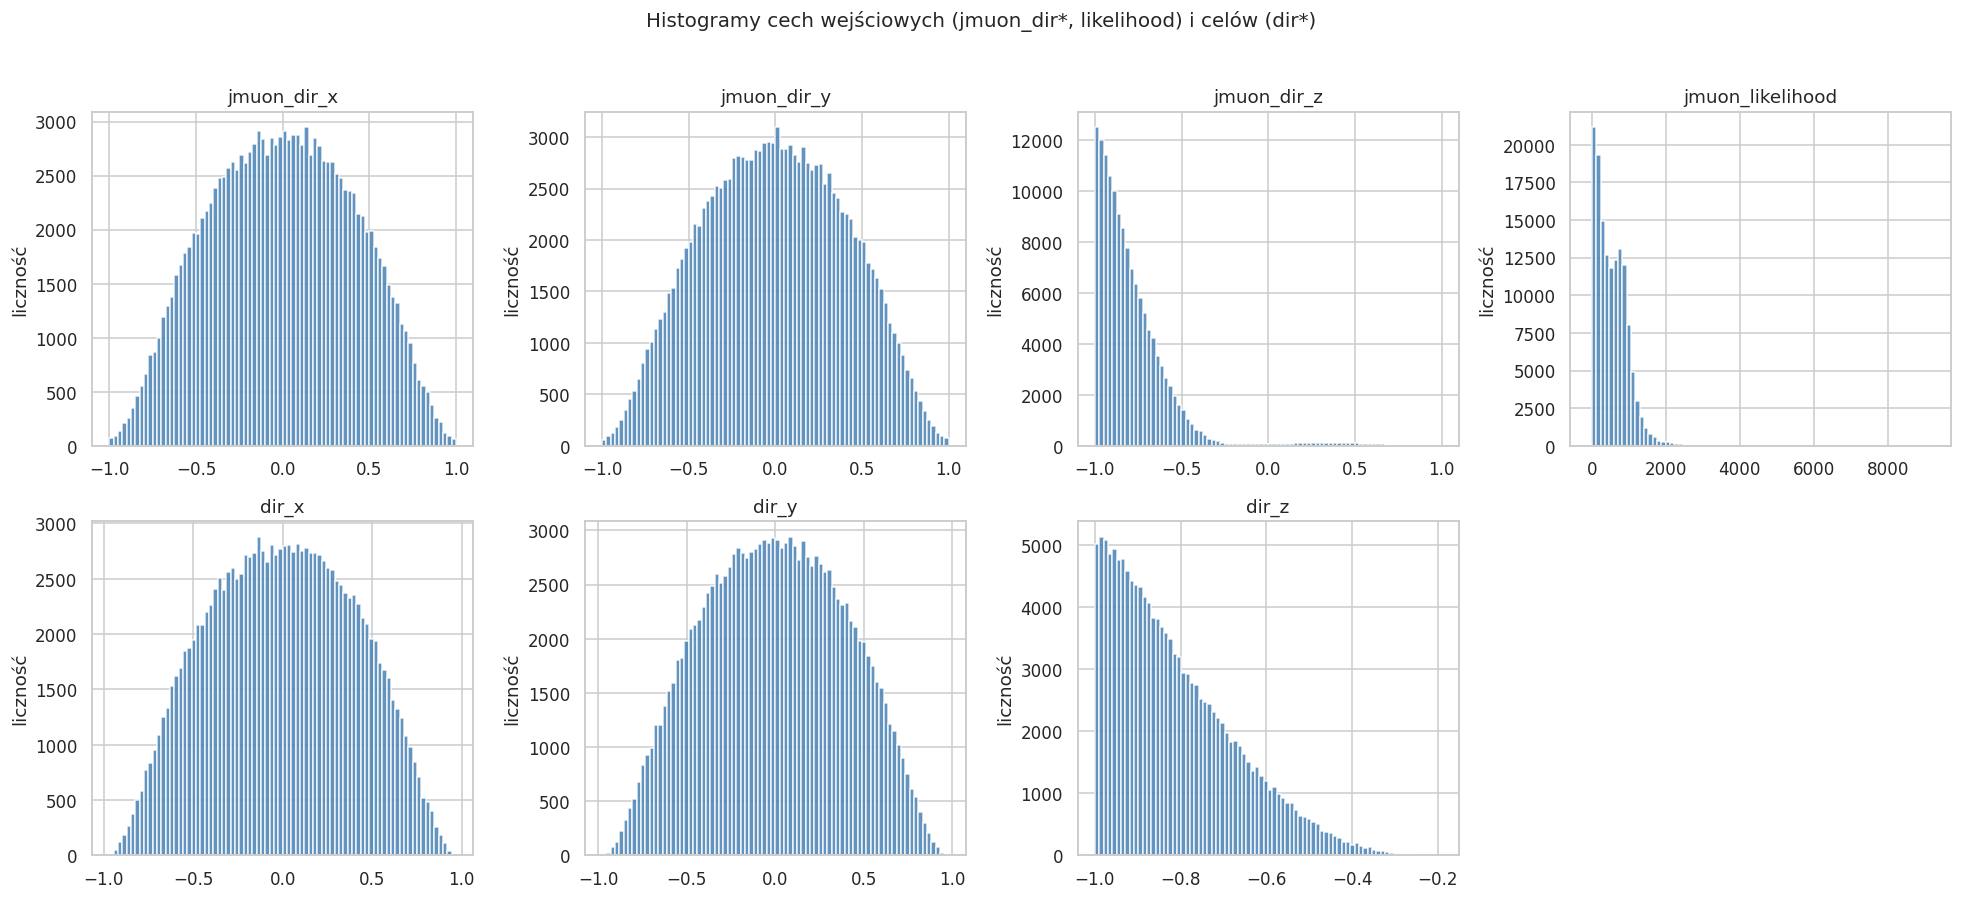

In [7]:
# Do wizualizacji używamy danych bez NaN (czyszczenie formalne nastąpi w preprocessingu).
eda = data.dropna().copy()
print("Zdarzeń do EDA:", len(eda))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), FEATURE_COLS + TARGET_COLS):
    ax.hist(eda[col], bins=80, color="steelblue", alpha=0.85)
    ax.set_title(col)
    ax.set_ylabel("liczność")
# Pusty ósmy panel
axes.ravel()[-1].axis("off")
fig.suptitle("Histogramy cech wejściowych (jmuon_dir*, likelihood) i celów (dir*)", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()

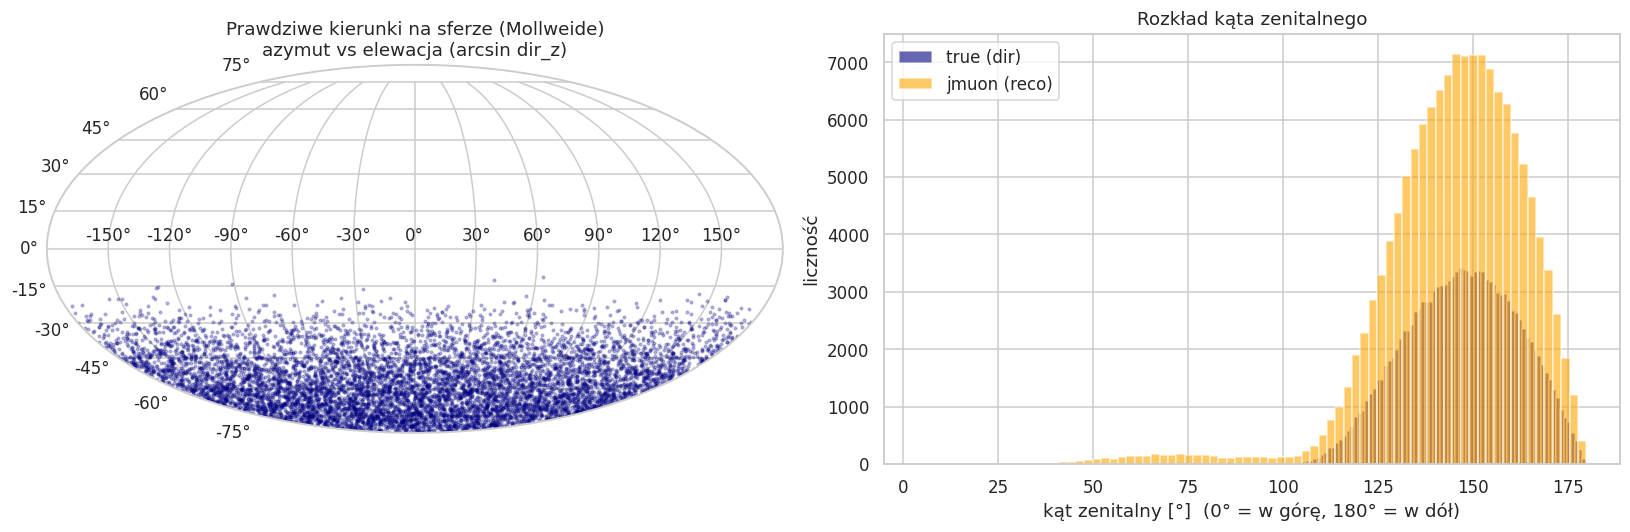

Wszystkie prawdziwe miony schodzące w dół (dir_z<0): 100.00%
Rekonstrukcje jmuon z dir_z>0 (ewidentnie błędne 'w górę'): 1.93%


In [10]:
# Rozkład kierunków na sferze.
# Współrzędne sferyczne: zenit = arccos(dir_z), azymut = atan2(dir_y, dir_x).
def to_sky(dx, dy, dz):
    lon = np.arctan2(dy, dx)            # [-pi, pi]
    lat = np.arcsin(np.clip(dz, -1, 1)) # [-pi/2, pi/2]
    return lon, lat

lon_t, lat_t = to_sky(eda["dir_x"], eda["dir_y"], eda["dir_z"])
zen_true = np.degrees(np.arccos(np.clip(eda["dir_z"], -1, 1)))
zen_reco = np.degrees(np.arccos(np.clip(eda["jmuon_dir_z"], -1, 1)))

fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="mollweide")
sample = np.random.default_rng(SEED).choice(len(eda), size=min(8000, len(eda)), replace=False)
ax1.scatter(lon_t.to_numpy()[sample], lat_t.to_numpy()[sample], s=3, alpha=0.25, color="navy")
ax1.set_title("Prawdziwe kierunki na sferze\nazymut vs elewacja (arcsin dir_z)")
ax1.grid(True)

ax2 = fig.add_subplot(1, 2, 2)
ax2.hist(zen_true, bins=80, alpha=0.6, label="true (dir)", color="navy")
ax2.hist(zen_reco, bins=80, alpha=0.6, label="jmuon (reco)", color="orange")
ax2.set_xlabel("kąt zenitalny [°]  (0° = w górę, 180° = w dół)")
ax2.set_ylabel("liczność")
ax2.set_title("Rozkład kąta zenitalnego")
ax2.legend()
fig.tight_layout()
plt.show()

print("Wszystkie prawdziwe miony schodzące w dół (dir_z<0): %.2f%%" % ((eda["dir_z"] < 0).mean() * 100))
print("Rekonstrukcje jmuon z dir_z>0 (ewidentnie błędne 'w górę'): %.2f%%" % ((eda["jmuon_dir_z"] > 0).mean() * 100))

## 6. Preprocessing

Kroki:
1. **Usunięcie wierszy z NaN** (kilkanaście nieudanych rekonstrukcji w kolumnach `jmuon_*`).
2. **(Re)normalizacja** `jmuon_dir` i `dir` do wektorów jednostkowych (formalność — w danych już są jednostkowe, ale zabezpieczamy się po czyszczeniu).
3. **Skalowanie `jmuon_likelihood`** — uwaga: zawiera wartości ujemne, więc log odpada; użyjemy `StandardScaler`. Scaler **fitujemy dopiero na zbiorze treningowym** (sekcja 7), aby uniknąć wycieku.

Tutaj wykonujemy kroki 1–2; skalowanie likelihood wykona się po podziale.

In [12]:
# 1) Czyszczenie NaN/inf
clean = data.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
print("Przed:", len(data), "| po usunięciu NaN:", len(clean), "| usunięto:", len(data) - len(clean))

# 2) Normalizacja kierunków do wektorów jednostkowych
def unit_rows(arr):
    arr = np.asarray(arr, dtype="float32")
    return arr / np.linalg.norm(arr, axis=1, keepdims=True)

X_dir = unit_rows(clean[["jmuon_dir_x", "jmuon_dir_y", "jmuon_dir_z"]].to_numpy())  # wejściowy kierunek
y_dir = unit_rows(clean[["dir_x", "dir_y", "dir_z"]].to_numpy())                     # cel (true)
likelihood = clean["jmuon_likelihood"].to_numpy(dtype="float32").reshape(-1, 1)

print("X_dir:", X_dir.shape, "| y_dir:", y_dir.shape, "| likelihood:", likelihood.shape)
print("Norma X_dir (powinna ~1):", np.linalg.norm(X_dir, axis=1).mean())

Przed: 139423 | po usunięciu NaN: 139408 | usunięto: 15
X_dir: (139408, 3) | y_dir: (139408, 3) | likelihood: (139408, 1)
Norma X_dir (powinna ~1): 1.0


## 7. Podział train / val / test

- Proporcje **70 / 15 / 15**.
- **Stratyfikacja po koszyku `dir_z` = cos(θ)** — żeby rozkład kątów zenitalnych był zgodny we wszystkich zbiorach.
- Grafy są niezależne per zdarzenie, więc **podział listy zdarzeń nie powoduje wycieku przez krawędzie**.
- `StandardScaler` dla `jmuon_likelihood` **fitujemy tylko na train** i stosujemy do val/test.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Koszyki cos(theta) = dir_z do stratyfikacji
strata = pd.qcut(y_dir[:, 2], q=10, labels=False, duplicates="drop")
idx = np.arange(len(y_dir))

idx_train, idx_tmp = train_test_split(idx, test_size=0.30, random_state=SEED, stratify=strata)
idx_val, idx_test = train_test_split(idx_tmp, test_size=0.50, random_state=SEED, stratify=strata[idx_tmp])

print("train:", len(idx_train), "| val:", len(idx_val), "| test:", len(idx_test))

# Skalowanie likelihood — fit tylko na train
scaler = StandardScaler().fit(likelihood[idx_train])
likelihood_scaled = scaler.transform(likelihood).astype("float32")
print("likelihood po skalowaniu — mean/std (train): %.3f / %.3f" % (
    likelihood_scaled[idx_train].mean(), likelihood_scaled[idx_train].std()))

train: 97585 | val: 20911 | test: 20912
likelihood po skalowaniu — mean/std (train): 0.000 / 1.000


## 8. Konstrukcja grafów (jedno zdarzenie = jeden graf)

Dla **każdego zdarzenia** budujemy graf PyG `Data`:

- **Węzły (4):** `jmuon_dir_x`, `jmuon_dir_y`, `jmuon_dir_z`, `jmuon_likelihood`. Cechy węzła to `[wartość, one-hot typu cechy]` (5 wymiarów) — `one-hot` pozwala modelowi rozróżniać role węzłów.
- **Krawędzie:** graf w pełni połączony **K4 + pętle własne** (16 skierowanych krawędzi). Przy 4 węzłach koszt jest znikomy, a warstwy EdgeConv/atencji same nauczą się wag interakcji.
- **Cel grafu (`y`):** `[dir_x, dir_y, dir_z]`.

Listy grafów ładujemy przez `torch_geometric.loader.DataLoader`, który batchuje wiele małych grafów (regresja na poziomie grafu, jak w DynEdge).

In [14]:
NUM_NODES = 4          # dir_x, dir_y, dir_z, likelihood
NODE_FEAT_DIM = 1 + NUM_NODES  # [wartość, one-hot(4)]

# Wspólny edge_index: pełny graf K4 + pętle własne (16 krawędzi skierowanych)
_pairs = [(i, j) for i in range(NUM_NODES) for j in range(NUM_NODES)]
EDGE_INDEX = torch.tensor(_pairs, dtype=torch.long).t().contiguous()
print("edge_index shape:", EDGE_INDEX.shape, "(2 x liczba_krawędzi)")

# Macierz cech węzłów dla wszystkich zdarzeń: [N, 4, 5]
# kolumna 0 = wartość skalarna, kolumny 1..4 = one-hot typu węzła
eye = np.eye(NUM_NODES, dtype="float32")
node_values = np.concatenate([X_dir, likelihood_scaled], axis=1)  # [N, 4] (dir_x,y,z, likelihood)
N = node_values.shape[0]
node_feats = np.zeros((N, NUM_NODES, NODE_FEAT_DIM), dtype="float32")
node_feats[:, :, 0] = node_values
node_feats[:, :, 1:] = eye  # broadcasting one-hot na każde zdarzenie

print("node_feats shape:", node_feats.shape)

def build_graphs(indices):
    feats = torch.from_numpy(node_feats[indices])   # [n, 4, 5]
    ys = torch.from_numpy(y_dir[indices])           # [n, 3]
    graphs = []
    for k in range(len(indices)):
        graphs.append(Data(x=feats[k], edge_index=EDGE_INDEX, y=ys[k].unsqueeze(0)))
    return graphs

train_graphs = build_graphs(idx_train)
val_graphs = build_graphs(idx_val)
test_graphs = build_graphs(idx_test)
print("Grafy — train/val/test:", len(train_graphs), len(val_graphs), len(test_graphs))
print("\nPrzykładowy graf:", train_graphs[0])

edge_index shape: torch.Size([2, 16]) (2 x liczba_krawędzi)
node_feats shape: (139408, 4, 5)
Grafy — train/val/test: 97585 20911 20912

Przykładowy graf: Data(x=[4, 5], edge_index=[2, 16], y=[1, 3])


In [15]:
BATCH_SIZE = 512
train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

# Podgląd jednego batcha (wiele małych grafów połączonych w jeden Batch)
_b = next(iter(train_loader))
print(_b)
print("Liczba grafów w batchu:", _b.num_graphs, "| węzłów łącznie:", _b.num_nodes)

DataBatch(x=[2048, 5], edge_index=[2, 8192], y=[512, 3], batch=[2048], ptr=[513])
Liczba grafów w batchu: 512 | węzłów łącznie: 2048


### 8a. Wizualizacja architektury grafu

Poniżej schemat pojedynczego grafu zdarzenia — 4 węzły-cechy połączone w K4, oraz przepływ `węzły → message-passing (EdgeConv/GAT) → global pooling → MLP → (reco_dir_x, reco_dir_y, reco_dir_z)`.

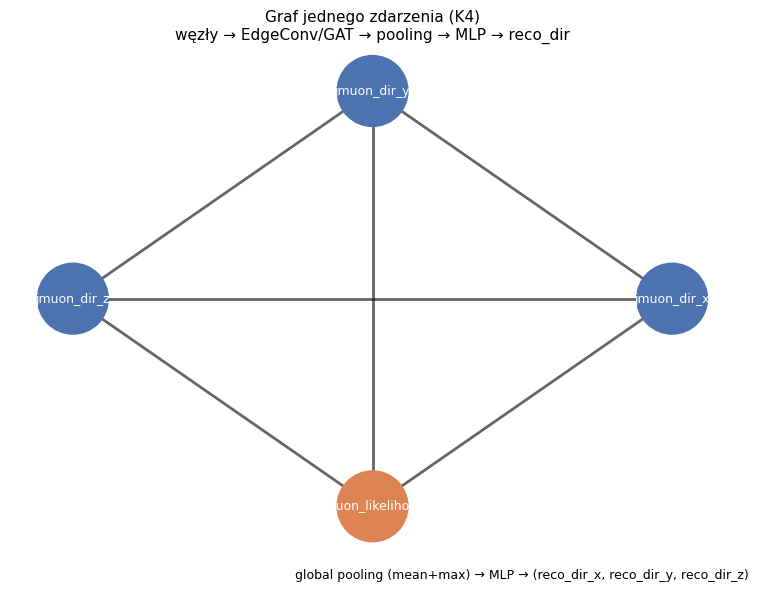

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# (a) Pojedynczy graf zdarzenia
node_labels = {0: "jmuon_dir_x", 1: "jmuon_dir_y", 2: "jmuon_dir_z", 3: "jmuon_likelihood"}
Gsingle = nx.Graph()
Gsingle.add_nodes_from(node_labels.keys())
Gsingle.add_edges_from([(i, j) for i in range(4) for j in range(i + 1, 4)])  # K4 (bez pętli dla czytelności)

fig, ax = plt.subplots(figsize=(8, 6))

pos = nx.circular_layout(Gsingle)
colors = ["#4c72b0", "#4c72b0", "#4c72b0", "#dd8452"]
nx.draw_networkx_nodes(Gsingle, pos, node_color=colors, node_size=2600, ax=ax)
nx.draw_networkx_edges(Gsingle, pos, width=2, alpha=0.6, ax=ax)
nx.draw_networkx_labels(Gsingle, pos, labels=node_labels, font_size=9, font_color="white", ax=ax)
ax.set_title("Graf jednego zdarzenia (K4)\nwęzły → EdgeConv/GAT → pooling → MLP → reco_dir", fontsize=11)
ax.axis("off")
ax.text(0.5, -1.35, "global pooling (mean+max) → MLP → (reco_dir_x, reco_dir_y, reco_dir_z)",
        ha="center", fontsize=9, transform=ax.transData)

fig.tight_layout()
plt.show()

## 9. Model GNN (schemat DynEdge)

Architektura zgodna z literaturą: `enkoder węzłów → bloki message-passing → global pooling → głowa MLP → kierunek`.

- **Warstwa message-passing** (wybierana parametrem): **EdgeConv** (DynEdge/ParticleNet — agreguje różnice par węzłów), **GAT** (atencja), **SAGE**/**GCN** (proste baseline'y).
- **Regularyzacja:** `Dropout` między blokami, `BatchNorm`, oraz `weight_decay` (L2) w optymalizatorze.
- **Pooling:** konkatenacja `global_mean_pool` + `global_max_pool`.
- **Głowa:** MLP → 3 wyjścia (kierunek), znormalizowane do wektora jednostkowego. Opcjonalnie dodatkowe wyjście `kappa` (dla straty von Mises–Fishera) — koduje niepewność per zdarzenie.

In [17]:
def make_conv(kind, dim):
    """Zwraca warstwę message-passing hidden->hidden danego typu."""
    kind = kind.lower()
    if kind == "edgeconv":
        mlp = nn.Sequential(nn.Linear(2 * dim, dim), nn.ReLU(), nn.Linear(dim, dim))
        return EdgeConv(nn=mlp, aggr="max")
    if kind == "gat":
        return GATConv(dim, dim, heads=4, concat=False)
    if kind == "sage":
        return SAGEConv(dim, dim)
    if kind == "gcn":
        return GCNConv(dim, dim)
    raise ValueError(f"Nieznany typ warstwy: {kind}")


class MuonGNN(nn.Module):
    def __init__(self, in_dim=NODE_FEAT_DIM, hidden=64, num_layers=3,
                 conv_type="edgeconv", dropout=0.2, pooling="meanmax", predict_kappa=False):
        super().__init__()
        self.predict_kappa = predict_kappa
        self.dropout = dropout
        self.pooling = pooling

        self.encoder = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU())
        self.convs = nn.ModuleList([make_conv(conv_type, hidden) for _ in range(num_layers)])
        self.norms = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(num_layers)])

        pool_dim = 2 * hidden if pooling == "meanmax" else hidden
        out_dim = 4 if predict_kappa else 3
        self.head = nn.Sequential(
            nn.Linear(pool_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
        )

    def _pool(self, x, batch):
        if self.pooling == "mean":
            return global_mean_pool(x, batch)
        if self.pooling == "max":
            return global_max_pool(x, batch)
        return torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.encoder(x)
        for conv, norm in zip(self.convs, self.norms):
            h = conv(x, edge_index)
            h = norm(h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            x = x + h  # połączenie rezydualne (stabilizuje głębsze sieci)
        pooled = self._pool(x, batch)
        out = self.head(pooled)

        direction = out[:, :3]
        direction = direction / (direction.norm(dim=1, keepdim=True) + 1e-8)
        if self.predict_kappa:
            kappa = F.softplus(out[:, 3]) + 1e-6  # dodatnia koncentracja
            return direction, kappa
        return direction, None


# Szybki test wymiarów na jednym batchu (CPU/GPU)
_m = MuonGNN().to(device)
_b = next(iter(train_loader)).to(device)
_d, _k = _m(_b)
print("Wyjście kierunku:", _d.shape, "| norma ~1:", _d.norm(dim=1).mean().item())
print("Liczba parametrów:", sum(p.numel() for p in _m.parameters()))
del _m, _b, _d, _k

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Wyjście kierunku: torch.Size([512, 3]) | norma ~1: 1.0
Liczba parametrów: 46467


## 10. Trening

**Funkcje straty** (wybierane parametrem `loss_type`):
- `angular` — `mean(1 - cos Δθ)`: prosta, zgodna z metryką kątową, nie wymaga `kappa`.
- `vmf` — negatywny log-likelihood rozkładu **von Mises–Fishera** (3D), model przewiduje też `kappa` (niepewność).
- `mix` — `kąt_otwarcia + 0.05·vMF` (technika ze zwycięskich rozwiązań IceCube).

**Dodatki:** Adam + **weight_decay (L2)**, scheduler `ReduceLROnPlateau`, **early stopping** (cierpliwość na walidacyjnym błędzie kątowym), checkpoint najlepszego modelu, **Dropout** w modelu.

In [18]:
import copy
import math

LN_2PI = math.log(2 * math.pi)

def vmf_nll(cos, kappa):
    """Negatywny log-likelihood rozkladu von Mises-Fishera dla wektorow 3D.
    -ln p = -kappa*cos + ln Z, gdzie Z = 2*pi*(e^k - e^-k)/k. Stabilnie numerycznie."""
    k = kappa.clamp(min=1e-4, max=80.0)
    log_norm = LN_2PI + k + torch.log1p(-torch.exp(-2 * k)) - torch.log(k)
    return -k * cos + log_norm

def compute_loss(dir_pred, kappa, y, loss_type):
    cos = (dir_pred * y).sum(dim=1).clamp(-1 + 1e-6, 1 - 1e-6)
    if loss_type == "angular":
        return (1 - cos).mean()
    if loss_type == "vmf":
        return vmf_nll(cos, kappa).mean()
    if loss_type == "mix":
        opening = torch.acos(cos).mean()
        return opening + 0.05 * vmf_nll(cos, kappa).mean()
    raise ValueError(loss_type)

@torch.no_grad()
def evaluate(model, loader, loss_type):
    model.eval()
    tot_loss, n = 0.0, 0
    angs = []
    for b in loader:
        b = b.to(device)
        y = b.y.view(-1, 3)
        dir_pred, kappa = model(b)
        loss = compute_loss(dir_pred, kappa, y, loss_type)
        bs = y.size(0)
        tot_loss += loss.item() * bs
        n += bs
        cos = (dir_pred * y).sum(1).clamp(-1, 1)
        angs.append(torch.rad2deg(torch.acos(cos)).cpu())
    angs = torch.cat(angs).numpy()
    return tot_loss / n, float(np.median(angs)), float(np.mean(angs))

In [19]:
def train_model(config, max_epochs=80, patience=12, verbose=True):
    set_seed(SEED)
    loss_type = config.get("loss_type", "angular")
    predict_kappa = loss_type in ("vmf", "mix")

    model = MuonGNN(
        hidden=config.get("hidden", 64),
        num_layers=config.get("num_layers", 3),
        conv_type=config.get("conv_type", "edgeconv"),
        dropout=config.get("dropout", 0.2),
        pooling=config.get("pooling", "meanmax"),
        predict_kappa=predict_kappa,
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=config.get("lr", 1e-3),
                           weight_decay=config.get("weight_decay", 1e-4))
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=4)

    history = {"train_loss": [], "val_loss": [], "val_med_ang": [], "val_mean_ang": [], "lr": []}
    best_val = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    bad = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        tot, n = 0.0, 0
        for b in train_loader:
            b = b.to(device)
            y = b.y.view(-1, 3)
            opt.zero_grad()
            dir_pred, kappa = model(b)
            loss = compute_loss(dir_pred, kappa, y, loss_type)
            loss.backward()
            opt.step()
            tot += loss.item() * y.size(0)
            n += y.size(0)
        train_loss = tot / n
        val_loss, val_med, val_mean = evaluate(model, val_loader, loss_type)
        sched.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_med_ang"].append(val_med)
        history["val_mean_ang"].append(val_mean)
        history["lr"].append(opt.param_groups[0]["lr"])

        # Early stopping wg walidacyjnej MEDIANY błędu kątowego (cel fizyczny)
        if val_med < best_val - 1e-4:
            best_val = val_med
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"epoch {epoch:3d} | train {train_loss:.4f} | val {val_loss:.4f} "
                  f"| val med ang {val_med:.3f}° | val mean ang {val_mean:.3f}° | lr {history['lr'][-1]:.1e}")
        if bad >= patience:
            if verbose:
                print(f"Early stopping na epoce {epoch} (brak poprawy przez {patience} epok).")
            break

    model.load_state_dict(best_state)
    return model, history, best_val

In [20]:
# Konfiguracja bazowa (referencyjna, przed tuningiem)
baseline_config = {
    "hidden": 64,
    "num_layers": 3,
    "conv_type": "edgeconv",
    "dropout": 0.2,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "loss_type": "angular",
}

base_model, base_history, base_val = train_model(baseline_config, max_epochs=80, patience=12)
print("\nNajlepsza walidacyjna mediana błędu kątowego (baseline):", round(base_val, 3), "°")

epoch   1 | train 0.0925 | val 0.0195 | val med ang 3.351° | val mean ang 6.182° | lr 1.0e-03
epoch   5 | train 0.0207 | val 0.0163 | val med ang 1.686° | val mean ang 4.431° | lr 1.0e-03
epoch  10 | train 0.0192 | val 0.0170 | val med ang 3.091° | val mean ang 5.439° | lr 1.0e-03
epoch  15 | train 0.0181 | val 0.0163 | val med ang 1.658° | val mean ang 4.533° | lr 5.0e-04
epoch  20 | train 0.0180 | val 0.0166 | val med ang 2.410° | val mean ang 5.165° | lr 5.0e-04
epoch  25 | train 0.0176 | val 0.0161 | val med ang 1.878° | val mean ang 4.550° | lr 2.5e-04
epoch  30 | train 0.0176 | val 0.0161 | val med ang 1.740° | val mean ang 4.464° | lr 2.5e-04
epoch  35 | train 0.0173 | val 0.0160 | val med ang 1.582° | val mean ang 4.341° | lr 1.3e-04
Early stopping na epoce 38 (brak poprawy przez 12 epok).

Najlepsza walidacyjna mediana błędu kątowego (baseline): 1.465 °


## 11. Krzywe uczenia

Strata train vs val, walidacyjny błąd kątowy (mediana/średnia) oraz krzywa learning rate. Rozjazd train/val sygnalizowałby przeuczenie (od tego mamy dropout, L2 i early stopping).

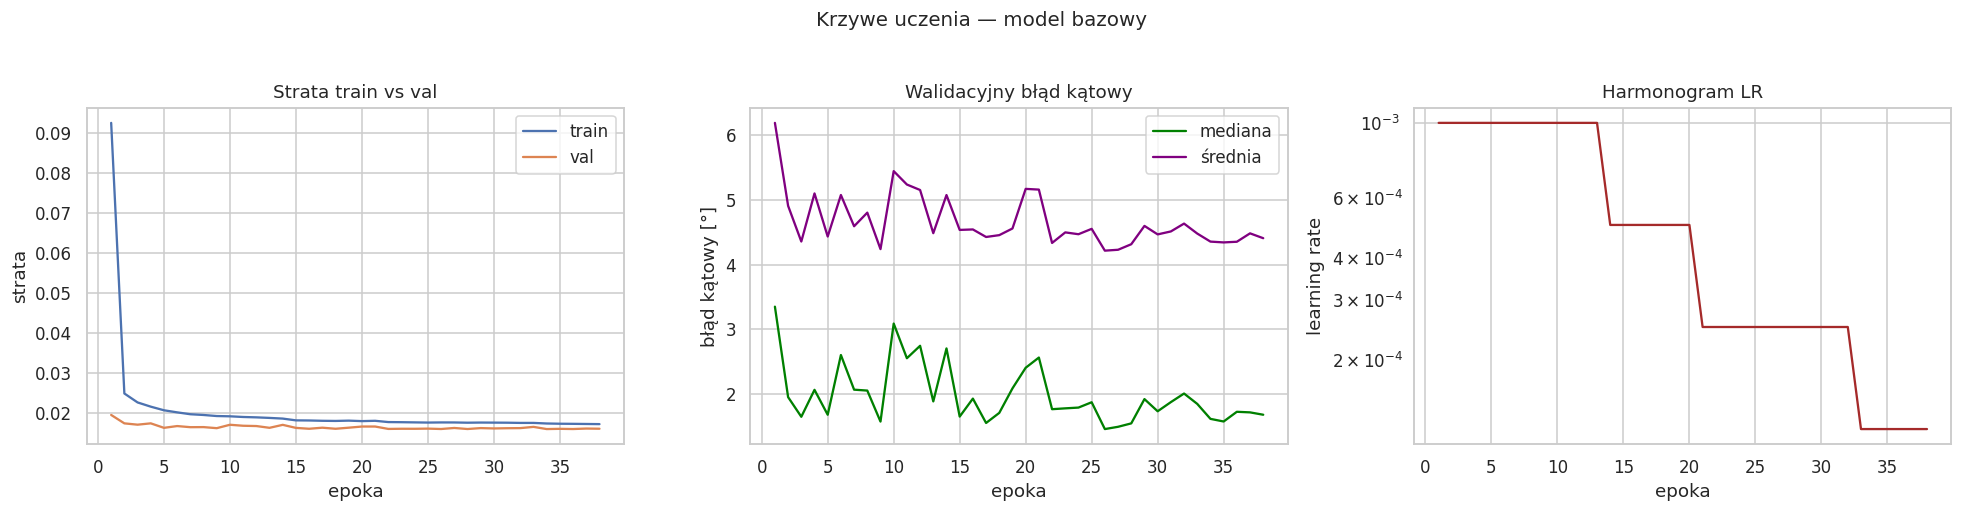

In [21]:
def plot_history(history, title="Krzywe uczenia"):
    ep = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    axes[0].plot(ep, history["train_loss"], label="train")
    axes[0].plot(ep, history["val_loss"], label="val")
    axes[0].set_xlabel("epoka"); axes[0].set_ylabel("strata"); axes[0].set_title("Strata train vs val")
    axes[0].legend()

    axes[1].plot(ep, history["val_med_ang"], label="mediana", color="green")
    axes[1].plot(ep, history["val_mean_ang"], label="średnia", color="purple")
    axes[1].set_xlabel("epoka"); axes[1].set_ylabel("błąd kątowy [°]")
    axes[1].set_title("Walidacyjny błąd kątowy"); axes[1].legend()

    axes[2].plot(ep, history["lr"], color="brown")
    axes[2].set_xlabel("epoka"); axes[2].set_ylabel("learning rate")
    axes[2].set_yscale("log"); axes[2].set_title("Harmonogram LR")
    fig.suptitle(title, y=1.03, fontsize=13)
    fig.tight_layout()
    plt.show()

plot_history(base_history, "Krzywe uczenia — model bazowy")

## 12. Tuning hiperparametrów (Optuna)

Przeszukujemy: `lr`, `hidden`, `num_layers`, `dropout`, `weight_decay`, typ warstwy (`edgeconv`/`gat`/`sage`/`gcn`), typ poolingu (`mean`/`max`/`meanmax`) oraz typ straty (`angular`/`vmf`/`mix`).

Kryterium wyboru: **walidacyjna mediana błędu kątowego**. Dla skrócenia czasu każda próba trenuje krócej (mniej epok, mniejsza cierpliwość); finalnie najlepszą konfigurację dotrenowujemy w pełni.

> Liczbę prób (`N_TRIALS`) i `max_epochs` dostosuj do dostępnego czasu GPU.

In [22]:
import optuna

N_TRIALS = 25  # zwiększ, jeśli masz czas GPU

def objective(trial):
    config = {
        "hidden": trial.suggest_categorical("hidden", [32, 64, 128]),
        "num_layers": trial.suggest_int("num_layers", 2, 4),
        "conv_type": trial.suggest_categorical("conv_type", ["edgeconv", "gat", "sage", "gcn"]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        "pooling": trial.suggest_categorical("pooling", ["mean", "max", "meanmax"]),
        "loss_type": trial.suggest_categorical("loss_type", ["angular", "vmf", "mix"]),
    }
    # Krótszy trening podczas tuningu
    _, _, best_val = train_model(config, max_epochs=30, patience=6, verbose=False)
    return best_val

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\nNajlepsza walidacyjna mediana błędu kątowego:", round(study.best_value, 4), "°")
print("Najlepsze hiperparametry:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-05-31 13:35:38,716] A new study created in memory with name: no-name-07c42ec2-3093-452d-8344-9a6ef4417d4a


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-05-31 13:37:02,547] Trial 0 finished with value: 1.1552133560180664 and parameters: {'hidden': 64, 'num_layers': 2, 'conv_type': 'gcn', 'dropout': 0.36140914942793106, 'lr': 0.00012013615259004702, 'weight_decay': 0.00029102650791698945, 'pooling': 'mean', 'loss_type': 'vmf'}. Best is trial 0 with value: 1.1552133560180664.
[I 2026-05-31 13:39:34,892] Trial 1 finished with value: 0.5918220281600952 and parameters: {'hidden': 128, 'num_layers': 2, 'conv_type': 'edgeconv', 'dropout': 0.15430247625605498, 'lr': 0.0008665503298387062, 'weight_decay': 0.00013348328530787498, 'pooling': 'mean', 'loss_type': 'vmf'}. Best is trial 1 with value: 0.5918220281600952.
[I 2026-05-31 13:42:09,187] Trial 2 finished with value: 0.9479131698608398 and parameters: {'hidden': 64, 'num_layers': 4, 'conv_type': 'sage', 'dropout': 0.3534721187607167, 'lr': 0.00029201156058638136, 'weight_decay': 5.586440718918822e-06, 'pooling': 'meanmax', 'loss_type': 'vmf'}. Best is trial 1 with value: 0.591822028

Trening finalnego modelu z konfiguracją: {'hidden': 128, 'num_layers': 2, 'conv_type': 'edgeconv', 'dropout': 0.15430247625605498, 'lr': 0.0008665503298387062, 'weight_decay': 0.00013348328530787498, 'pooling': 'mean', 'loss_type': 'vmf'}
epoch   1 | train -0.5499 | val -1.6550 | val med ang 2.762° | val mean ang 5.527° | lr 8.7e-04
epoch   5 | train -1.8936 | val -2.0265 | val med ang 1.612° | val mean ang 4.201° | lr 8.7e-04
epoch  10 | train -1.9404 | val -2.0175 | val med ang 1.564° | val mean ang 4.082° | lr 8.7e-04
epoch  15 | train -1.9540 | val -2.0427 | val med ang 1.282° | val mean ang 4.104° | lr 8.7e-04
epoch  20 | train -1.9692 | val -2.0536 | val med ang 0.930° | val mean ang 3.747° | lr 8.7e-04
epoch  25 | train -1.9755 | val -2.0381 | val med ang 1.451° | val mean ang 4.135° | lr 8.7e-04
epoch  30 | train -1.9910 | val -2.0617 | val med ang 0.642° | val mean ang 3.471° | lr 4.3e-04
epoch  35 | train -1.9897 | val -2.0547 | val med ang 0.831° | val mean ang 3.611° | lr 2

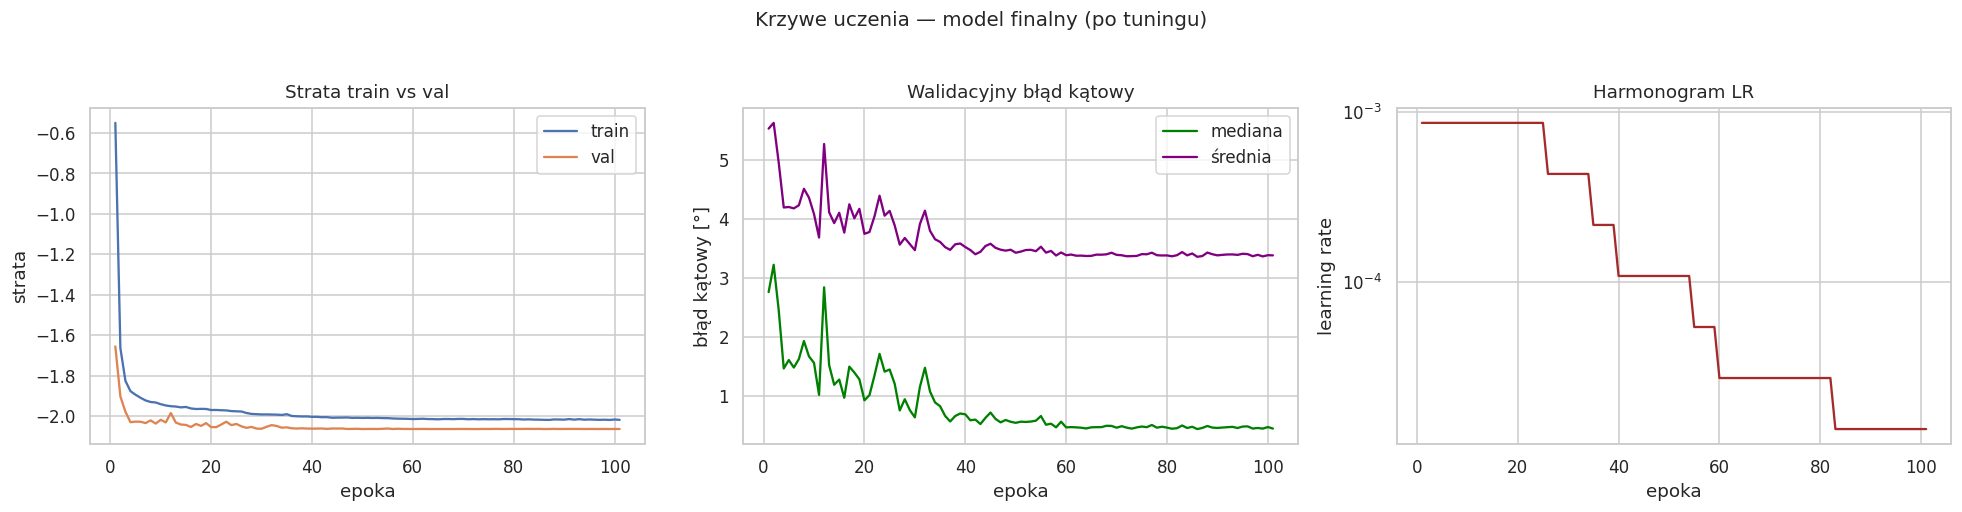


Walidacyjna mediana błędu kątowego (finalny): 0.444 °
Do ewaluacji wybrano model FINALNY (po tuningu).


In [23]:
# Dotrenowanie najlepszej konfiguracji w pełnym budżecie epok
best_config = dict(study.best_params)
print("Trening finalnego modelu z konfiguracją:", best_config)

final_model, final_history, final_val = train_model(best_config, max_epochs=120, patience=15)
plot_history(final_history, "Krzywe uczenia — model finalny (po tuningu)")
print("\nWalidacyjna mediana błędu kątowego (finalny):", round(final_val, 3), "°")

# Wybór modelu do ewaluacji: lepszy z (bazowy, finalny)
if final_val <= base_val:
    best_model, best_loss_type = final_model, best_config.get("loss_type", "angular")
    print("Do ewaluacji wybrano model FINALNY (po tuningu).")
else:
    best_model, best_loss_type = base_model, baseline_config["loss_type"]
    print("Do ewaluacji wybrano model BAZOWY.")

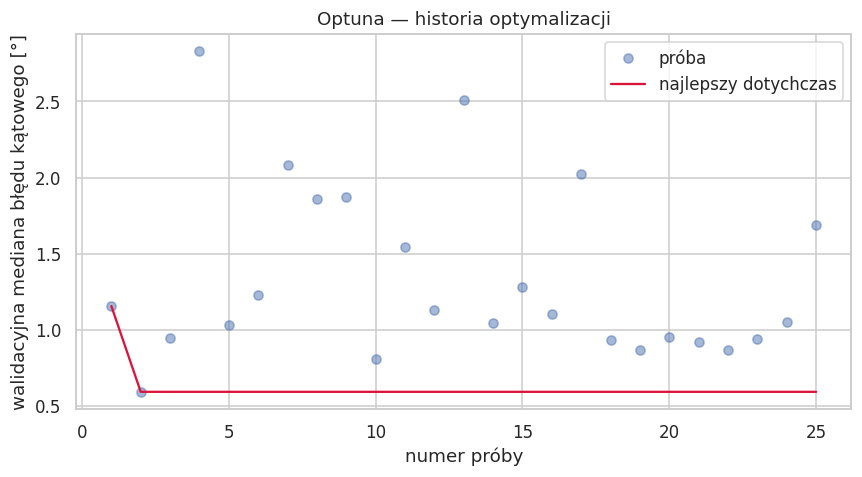

In [24]:
# Historia optymalizacji Optuna (najlepszy wynik narastająco)
vals = [t.value for t in study.trials if t.value is not None]
best_so_far = np.minimum.accumulate(vals)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, len(vals) + 1), vals, "o", alpha=0.5, label="próba")
ax.plot(range(1, len(vals) + 1), best_so_far, "-", color="crimson", label="najlepszy dotychczas")
ax.set_xlabel("numer próby"); ax.set_ylabel("walidacyjna mediana błędu kątowego [°]")
ax.set_title("Optuna — historia optymalizacji"); ax.legend()
fig.tight_layout()
plt.show()

## 13. Ewaluacja na zbiorze testowym

Najpierw zbieramy predykcje na zbiorze testowym, a następnie generujemy komplet wykresów:
- histogramy residuów (per składowa x/y/z + residuum kątowe),
- histogram **pull** z nałożonym rozkładem Gaussa,
- residua vs predykcja,
- **q-q plot** residuów,
- **MAE vs true** (binowane),
- **pred vs true**.

`residuum = pred - true`.

In [25]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    preds, kappas, trues = [], [], []
    for b in loader:
        b = b.to(device)
        dir_pred, kappa = model(b)
        preds.append(dir_pred.cpu().numpy())
        trues.append(b.y.view(-1, 3).cpu().numpy())
        kappas.append(kappa.cpu().numpy() if kappa is not None else np.full(dir_pred.shape[0], np.nan))
    return np.concatenate(preds), np.concatenate(trues), np.concatenate(kappas)

pred, true, kappa = predict(best_model, test_loader)
residual = pred - true                         # [N, 3]
ang_err = angular_error_deg(pred, true)        # [N] w stopniach
comp_names = ["dir_x", "dir_y", "dir_z"]

print("Test — błąd kątowy modelu:")
summarize_angles(ang_err, "GNN (test)")
print("\nMAE per składowa:", {c: round(float(np.mean(np.abs(residual[:, i]))), 4)
                              for i, c in enumerate(comp_names)})

Test — błąd kątowy modelu:
=== Błąd kątowy: GNN (test) (stopnie) ===
   16 percentyl:   0.181
   50 percentyl:   0.441
   68 percentyl:   0.775
   84 percentyl:   2.059
   95 percentyl:  21.278
  średnia: 3.284 | max: 105.632 | frakcja > 5°: 10.60%

MAE per składowa: {'dir_x': 0.0336, 'dir_y': 0.0316, 'dir_z': 0.0175}


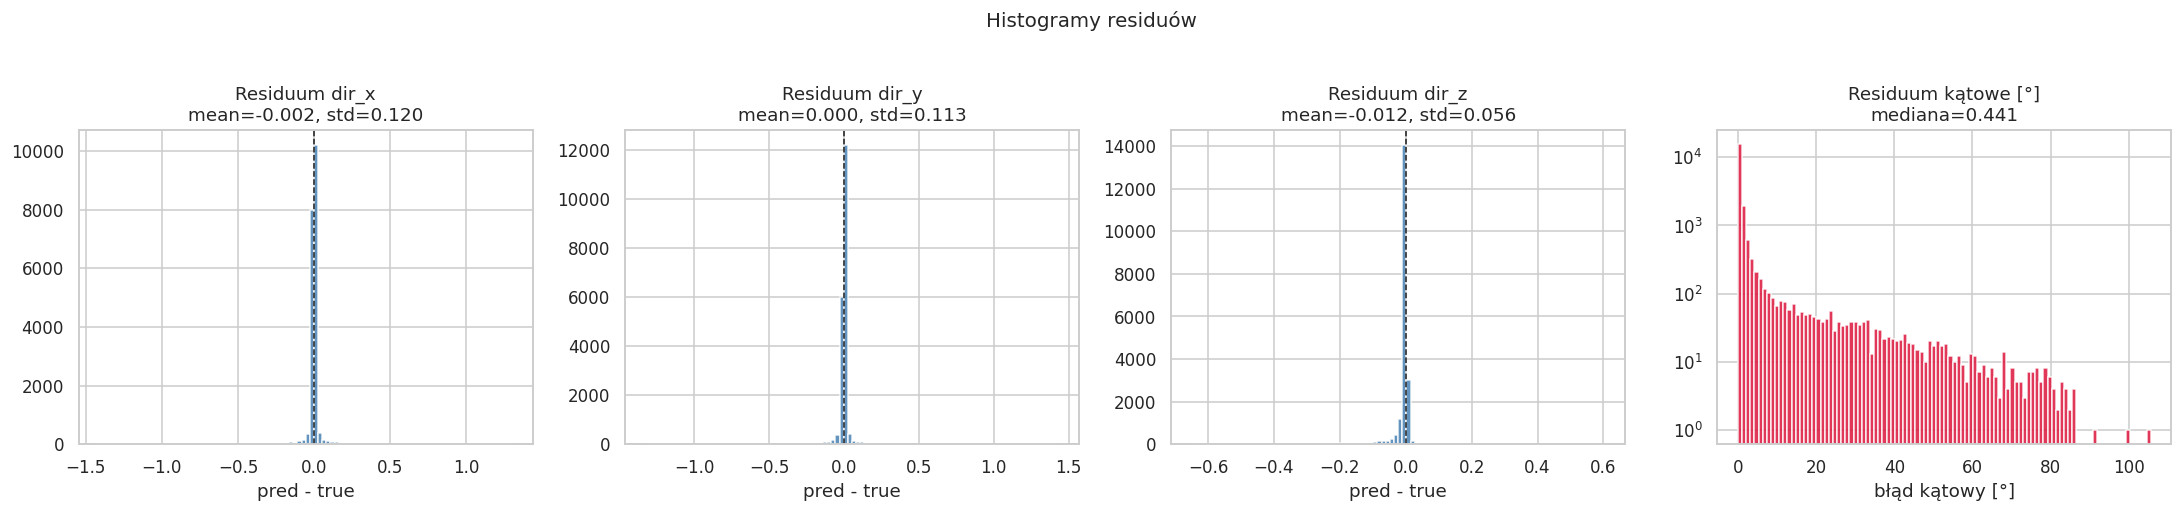

In [26]:
# 13.1 Histogramy residuów (per składowa + residuum kątowe)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for i, c in enumerate(comp_names):
    r = residual[:, i]
    axes[i].hist(r, bins=100, color="steelblue", alpha=0.85)
    axes[i].axvline(0, color="k", ls="--", lw=1)
    axes[i].set_title(f"Residuum {c}\nmean={r.mean():.3f}, std={r.std():.3f}")
    axes[i].set_xlabel("pred - true")
axes[3].hist(ang_err, bins=100, color="crimson", alpha=0.85)
axes[3].set_yscale("log")
axes[3].set_title(f"Residuum kątowe [°]\nmediana={np.median(ang_err):.3f}")
axes[3].set_xlabel("błąd kątowy [°]")
fig.suptitle("Histogramy residuów", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

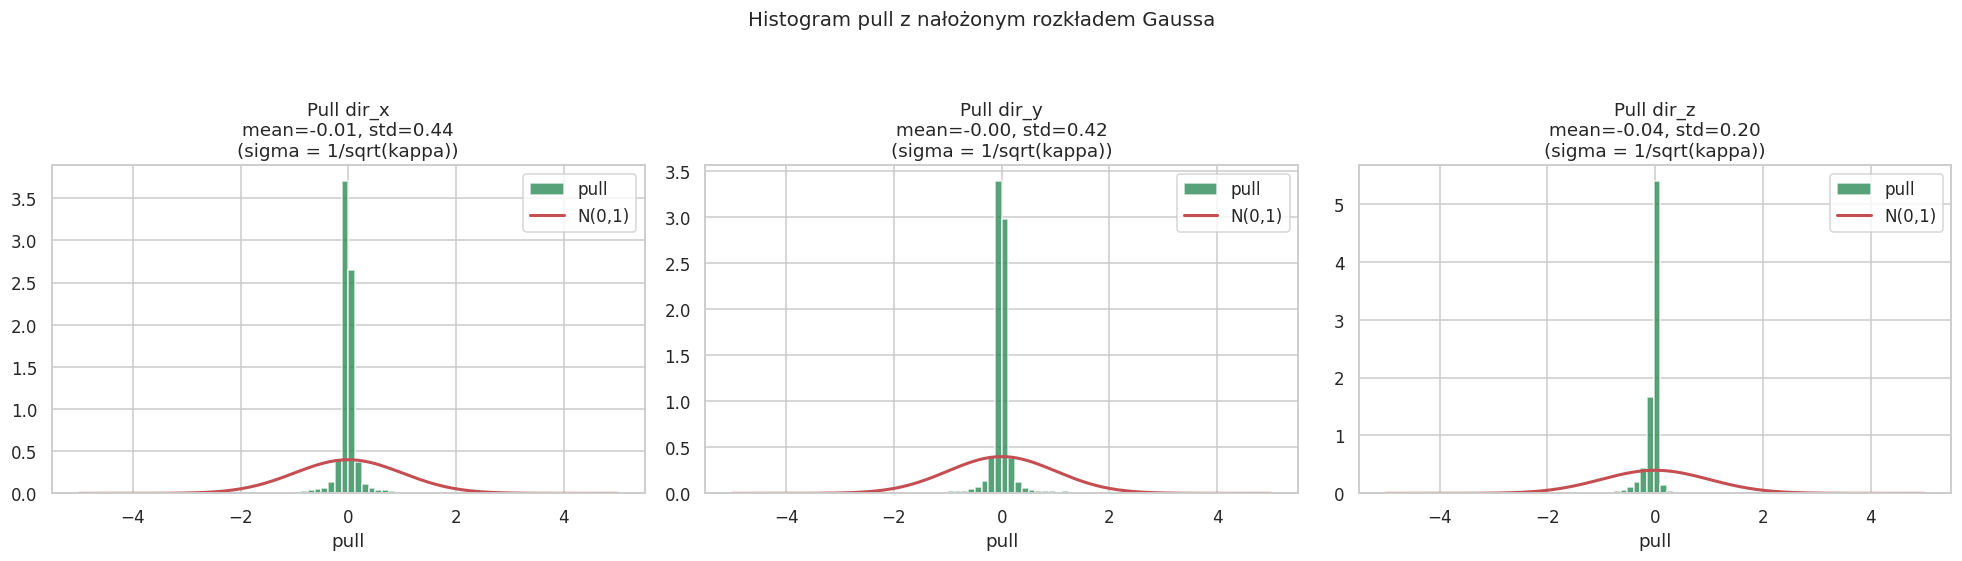

In [27]:
# 13.2 Histogram pull z nałożonym rozkładem Gaussa
# Pull = residuum / sigma. Jeśli model przewiduje kappa (vMF), sigma per zdarzenie = 1/sqrt(kappa);
# w przeciwnym razie standaryzujemy globalnym odchyleniem residuum danej składowej.
has_kappa = not np.isnan(kappa).all()
xx = np.linspace(-5, 5, 200)
gauss = stats.norm.pdf(xx, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for i, c in enumerate(comp_names):
    r = residual[:, i]
    if has_kappa:
        sigma = 1.0 / np.sqrt(kappa)      # per zdarzenie (kątowe, przybliżenie per składowa)
        pull = r / sigma
        sub = "sigma = 1/sqrt(kappa)"
    else:
        pull = r / r.std()
        sub = "sigma = std(residuum)"
    pull = pull[np.isfinite(pull)]
    pull = np.clip(pull, -5, 5)
    axes[i].hist(pull, bins=80, density=True, color="seagreen", alpha=0.8, label="pull")
    axes[i].plot(xx, gauss, "r-", lw=2, label="N(0,1)")
    axes[i].set_title(f"Pull {c}\nmean={pull.mean():.2f}, std={pull.std():.2f}\n({sub})")
    axes[i].set_xlabel("pull"); axes[i].legend()
fig.suptitle("Histogram pull z nałożonym rozkładem Gaussa", y=1.06, fontsize=13)
fig.tight_layout()
plt.show()

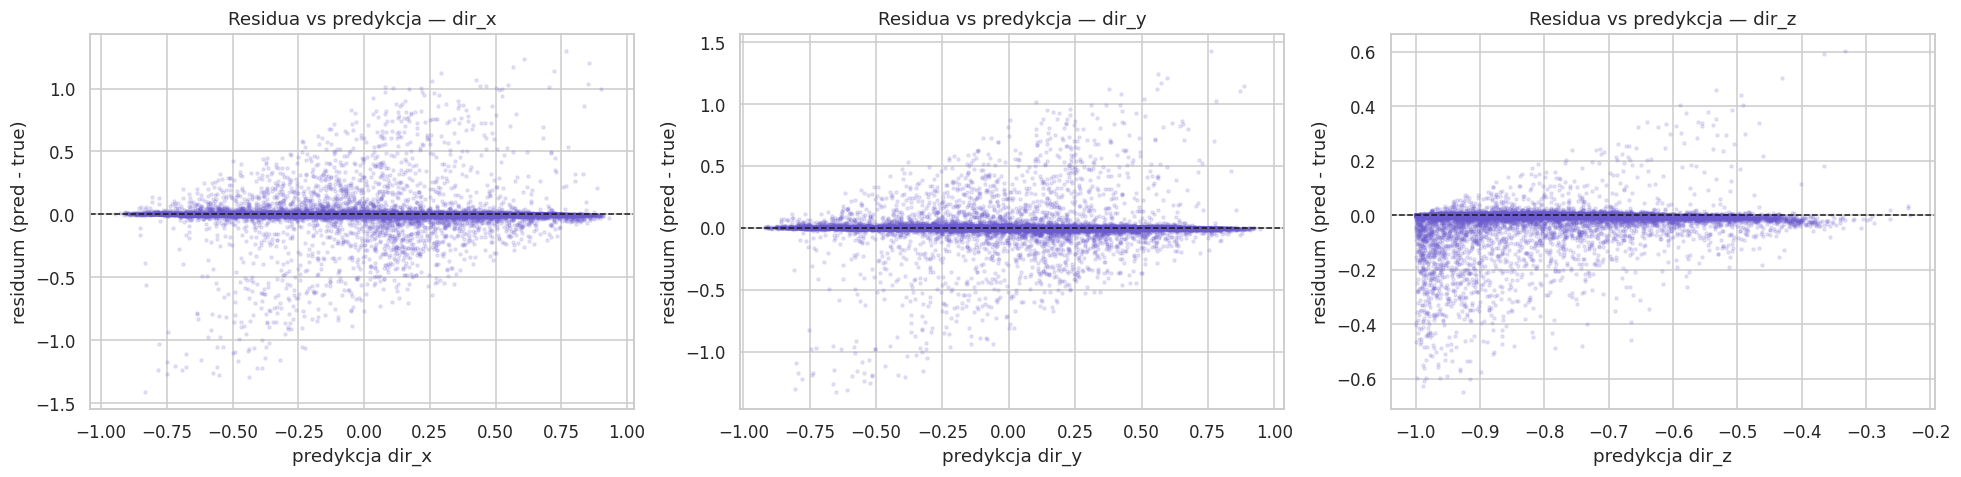

In [28]:
# 13.3 Residua vs predykcja (sprawdzenie zależności residuum od wartości przewidywanej)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for i, c in enumerate(comp_names):
    axes[i].scatter(pred[:, i], residual[:, i], s=4, alpha=0.15, color="slateblue")
    axes[i].axhline(0, color="k", ls="--", lw=1)
    axes[i].set_xlabel(f"predykcja {c}"); axes[i].set_ylabel("residuum (pred - true)")
    axes[i].set_title(f"Residua vs predykcja — {c}")
fig.tight_layout()
plt.show()

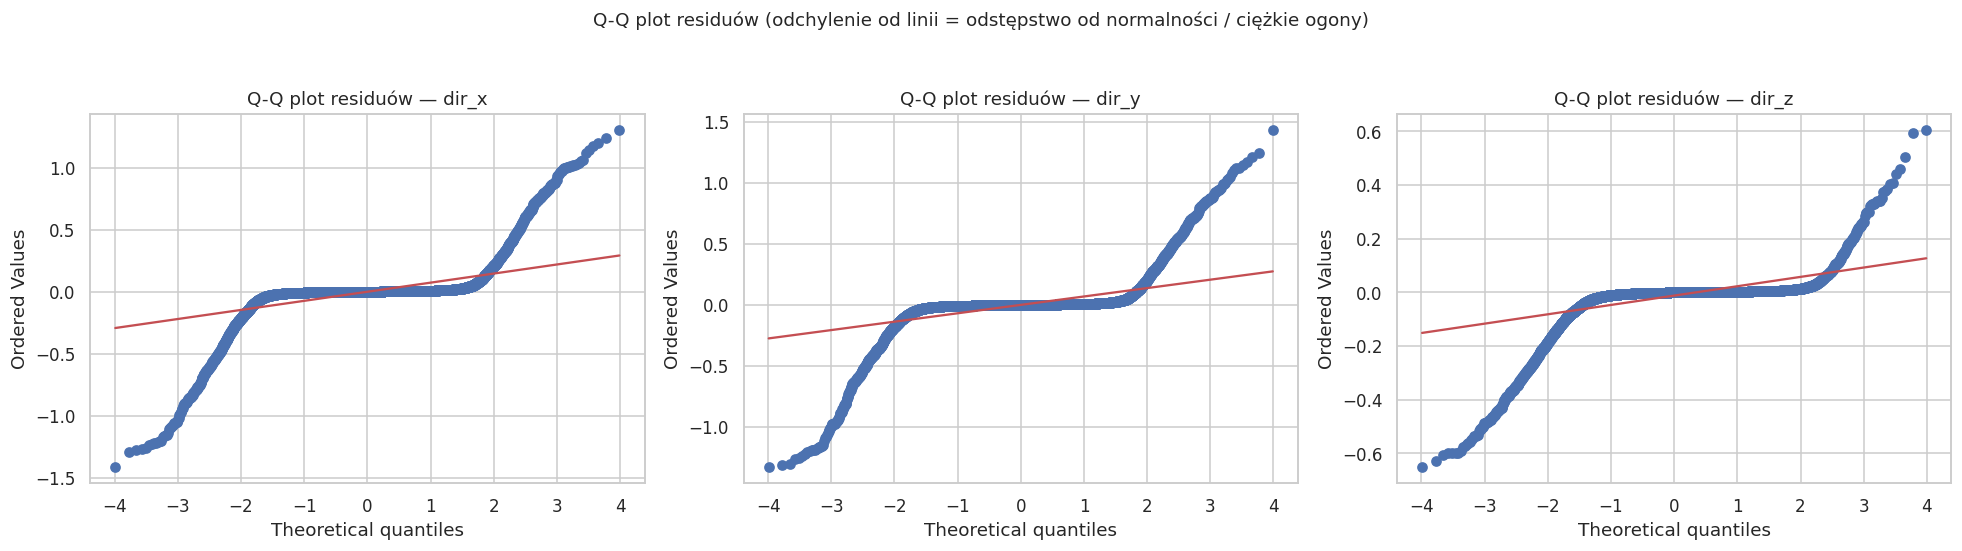

In [29]:
# 13.4 Q-Q plot residuów (porównanie z rozkładem normalnym)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for i, c in enumerate(comp_names):
    stats.probplot(residual[:, i], dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q plot residuów — {c}")
fig.suptitle("Q-Q plot residuów (odchylenie od linii = odstępstwo od normalności / ciężkie ogony)",
             y=1.04, fontsize=12)
fig.tight_layout()
plt.show()

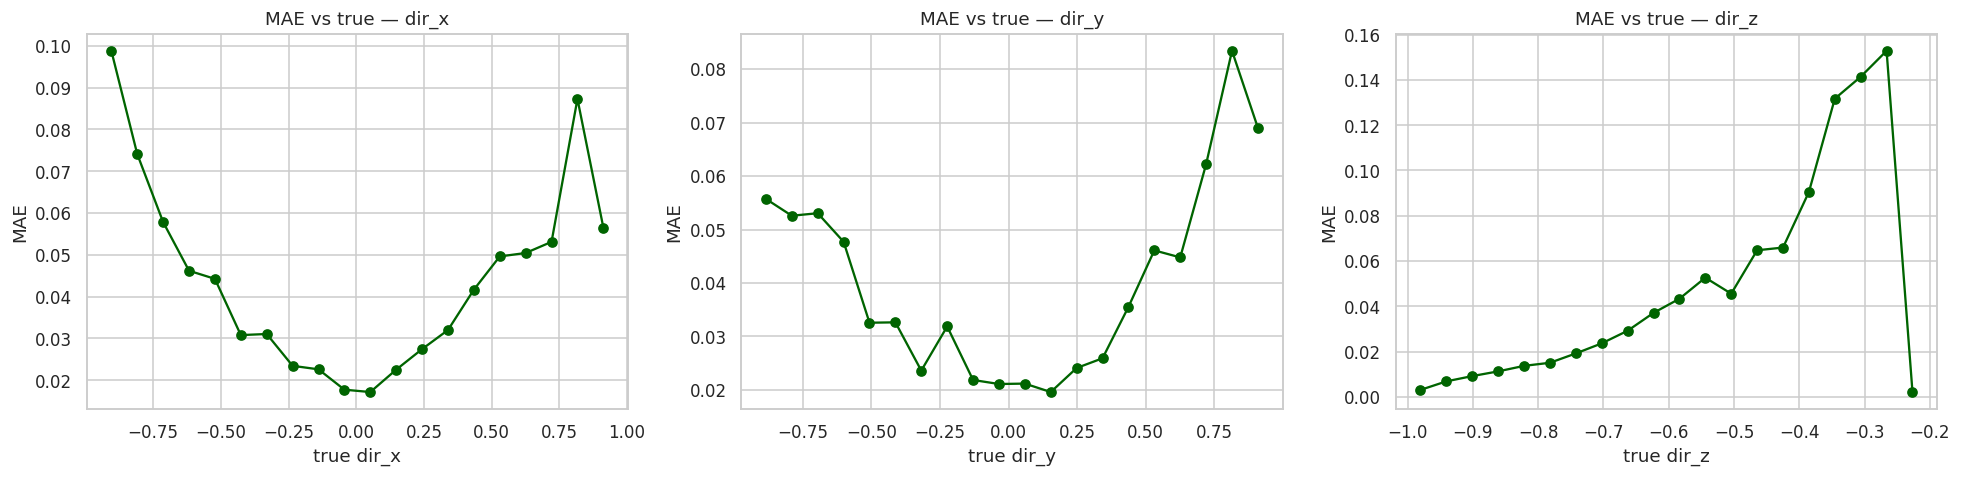

In [30]:
# 13.5 MAE vs true (błąd bezwzględny w funkcji wartości prawdziwej)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for i, c in enumerate(comp_names):
    t = true[:, i]
    ae = np.abs(residual[:, i])
    bins = np.linspace(t.min(), t.max(), 21)
    centers = 0.5 * (bins[:-1] + bins[1:])
    idx_bin = np.digitize(t, bins) - 1
    mae_bin = [ae[idx_bin == b].mean() if np.any(idx_bin == b) else np.nan for b in range(len(centers))]
    axes[i].plot(centers, mae_bin, "o-", color="darkgreen")
    axes[i].set_xlabel(f"true {c}"); axes[i].set_ylabel("MAE")
    axes[i].set_title(f"MAE vs true — {c}")
fig.tight_layout()
plt.show()

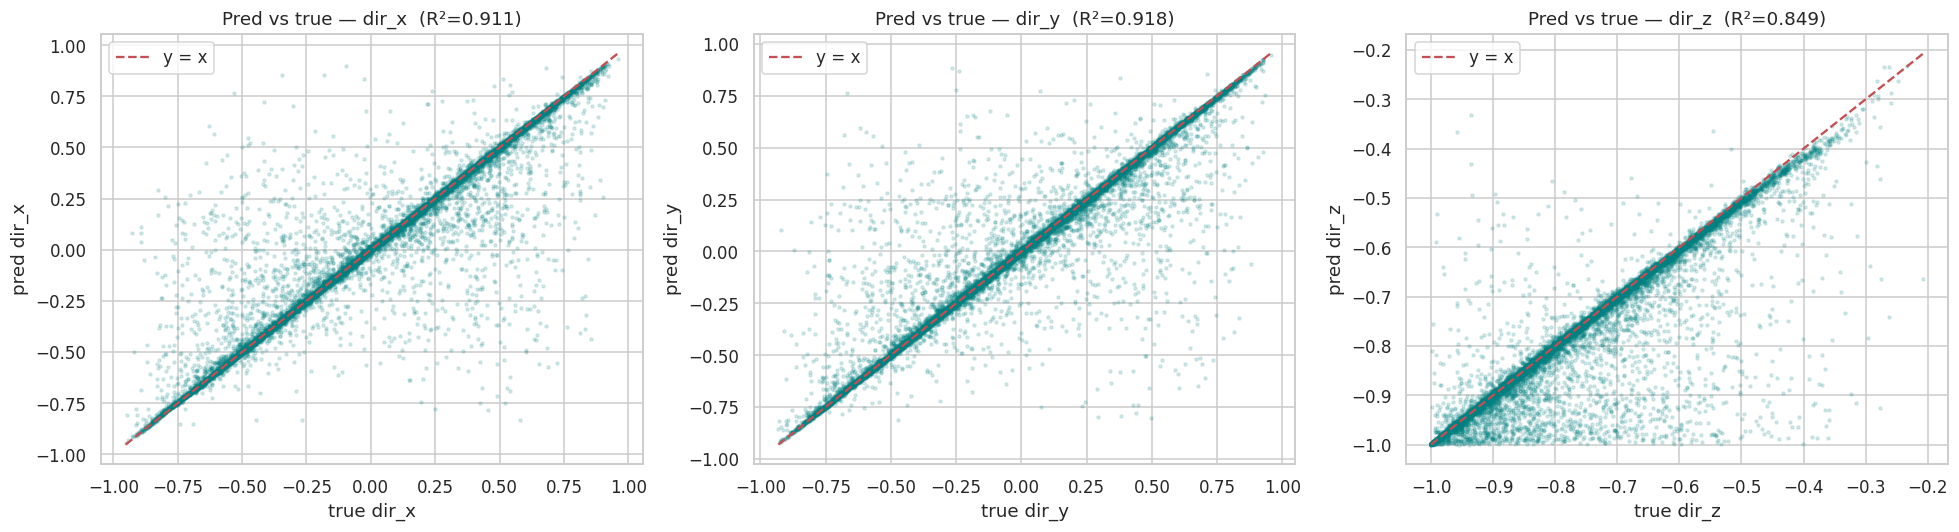

In [31]:
# 13.6 Pred vs true (idealnie punkty leżą na linii y = x)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, c in enumerate(comp_names):
    axes[i].scatter(true[:, i], pred[:, i], s=4, alpha=0.15, color="teal")
    lim = [min(true[:, i].min(), pred[:, i].min()), max(true[:, i].max(), pred[:, i].max())]
    axes[i].plot(lim, lim, "r--", lw=1.5, label="y = x")
    r2 = np.corrcoef(true[:, i], pred[:, i])[0, 1] ** 2
    axes[i].set_xlabel(f"true {c}"); axes[i].set_ylabel(f"pred {c}")
    axes[i].set_title(f"Pred vs true — {c}  (R²={r2:.3f})")
    axes[i].legend()
fig.tight_layout()
plt.show()

## 14. Porównanie z baseline (klasyczna rekonstrukcja jmuon)

Porównujemy błąd kątowy **modelu GNN** z błędem surowej rekonstrukcji **jmuon_dir** na tym samym zbiorze testowym. Mediana baseline jest bardzo dobra (~0.3°), więc kluczowe jest **ujarzmienie ogona** dużych błędów (wysokie percentyle i frakcja błędów > 5°).

metoda                         median      p68      p95     mean    frac>5°
baseline jmuon_dir              0.318    0.592   31.864    4.516      8.36%
model GNN                       0.441    0.775   21.278    3.284     10.60%


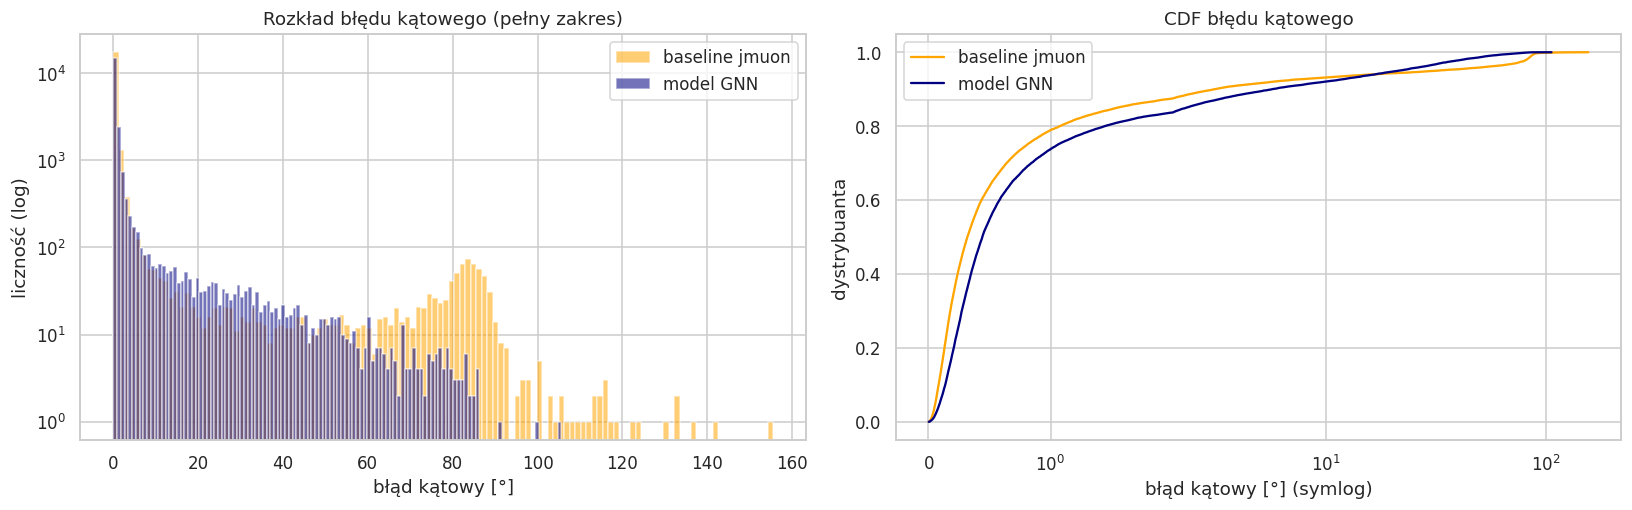

In [32]:
# Baseline na zbiorze testowym: jmuon_dir vs prawda
baseline_test = angular_error_deg(X_dir[idx_test], y_dir[idx_test])

print("%-28s %8s %8s %8s %8s %10s" % ("metoda", "median", "p68", "p95", "mean", "frac>5°"))
for name, ang in [("baseline jmuon_dir", baseline_test), ("model GNN", ang_err)]:
    print("%-28s %8.3f %8.3f %8.3f %8.3f %9.2f%%" % (
        name, np.median(ang), np.percentile(ang, 68), np.percentile(ang, 95),
        ang.mean(), (ang > 5).mean() * 100))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].hist(baseline_test, bins=120, alpha=0.55, label="baseline jmuon", color="orange")
axes[0].hist(ang_err, bins=120, alpha=0.55, label="model GNN", color="navy")
axes[0].set_yscale("log")
axes[0].set_xlabel("błąd kątowy [°]"); axes[0].set_ylabel("liczność (log)")
axes[0].set_title("Rozkład błędu kątowego (pełny zakres)"); axes[0].legend()

# Skumulowana dystrybuanta błędu kątowego
for ang, lab, col in [(baseline_test, "baseline jmuon", "orange"), (ang_err, "model GNN", "navy")]:
    xs = np.sort(ang)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    axes[1].plot(xs, ys, label=lab, color=col)
axes[1].set_xscale("symlog")
axes[1].set_xlabel("błąd kątowy [°] (symlog)"); axes[1].set_ylabel("dystrybuanta")
axes[1].set_title("CDF błędu kątowego"); axes[1].legend()
fig.tight_layout()
plt.show()